In [2]:
# This code generates input for figure 4.
import math
#
#
def calcular_longitud_onda(d, theta_i_grados, theta_m_grados):
    """
    Calculates the diffracted wavelength as a function of the incident
   angle and the diffracted angle.

    Args:
        d (float): spacing.
        theta_i_grados (float): incident angle in degrees.
        theta_m_grados (float): diffraction angle in degrees.

    Returns:
        float: wavelength in nm.
    """
    # Convertion from degrees to radians
    theta_i_rad = math.radians(theta_i_grados)
    theta_m_rad = math.radians(theta_m_grados)

    # Wavelength calculation
    lambda_val = 1.33*d * (math.sin(theta_m_rad) - math.sin(theta_i_rad))*1E9
    return lambda_val

def calcular_longitud_onda_corte(d, theta_i_grados):
  """
    Calculates cutt off wavelength
    Args:
        d (float): Spacing.
        theta_i_grados (float): Incident angle in degrees.
            Returns:
        float: calculated cut off wavelength    """
  theta_i_rad = math.radians(theta_i_grados)
   # Wavelength calculation
  lambda_val_cut = 1.33*d* (1.00 - math.sin(theta_i_rad))*1E9
  return lambda_val_cut

# Example of use:
d_val = 0.0000010 # Puedes cambiar este valor
theta_i_val = 0 # Puedes cambiar este valor
theta_m_val = 45 # Puedes cambiar este valor

resultado_lambda = calcular_longitud_onda(d_val, theta_i_val, theta_m_val)
print(f"The calculated wavelength, in nm,  is: {resultado_lambda}")
resultado_lambda_cut = calcular_longitud_onda_corte(d_val, theta_i_val)
print(f"The cut-off wavelength, in nm, is: {resultado_lambda_cut}")

The calculated wavelength, in nm,  is: 940.4520189781081
The cut-off wavelength, in nm, is: 1330.0


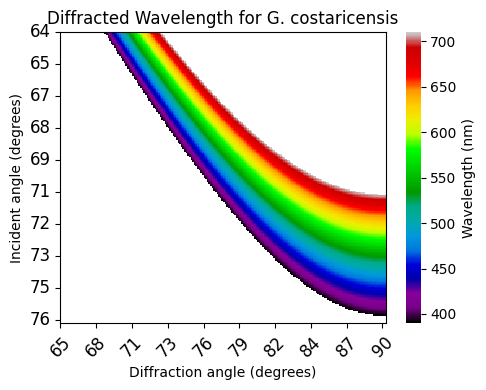

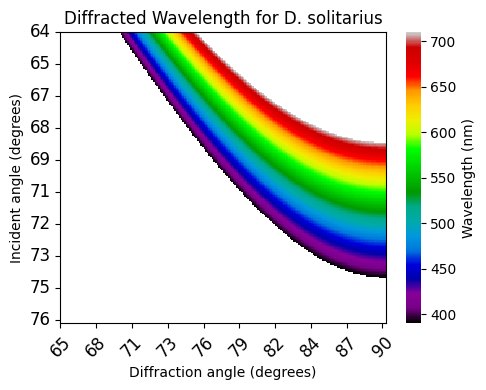

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Defines the value for d
d_heatmap_gc = 0.0000095 # spacing for species gc
d_heatmap_ds = 0.0000077 # spacing for species ds
# Definir los rangos de ángulos en grados
theta_i_range = np.linspace(64, 76, 200) #I Incidence angle, between 0 and 90 degres
theta_m_range = np.linspace(65, 90, 200) # Diffraction angle, between 0 and 90 grados


# Creates a matrix to storage lambda values
lambda_matrix_gc = np.zeros((len(theta_i_range), len(theta_m_range)))
lambda_vector_cut_gc=np.zeros(len(theta_i_range))

lambda_matrix_ds = np.zeros((len(theta_i_range), len(theta_m_range)))
lambda_vector_cut_ds=np.zeros(len(theta_i_range))

# Calculates lambda for each combination of angles
for i, theta_i in enumerate(theta_i_range):
  #for species gc
    lambda_vector_cut_gc[i]=calcular_longitud_onda_corte(d_heatmap_gc, theta_i)
  #for species ds
    lambda_vector_cut_ds[i]=calcular_longitud_onda_corte(d_heatmap_ds, theta_i)

    for j, theta_m in enumerate(theta_m_range):
        lambda_matrix_gc[i, j] = calcular_longitud_onda(d_heatmap_gc, theta_i, theta_m)
        lambda_matrix_ds[i, j] = calcular_longitud_onda(d_heatmap_ds, theta_i, theta_m)
# Set negative lambda values to NaN so they are not plotted (represented as
# blank)
lambda_matrix_gc[lambda_matrix_gc < 390] = np.nan
lambda_matrix_gc[lambda_matrix_gc > 710] = np.nan

lambda_matrix_ds[lambda_matrix_ds < 390] = np.nan
lambda_matrix_ds[lambda_matrix_ds > 710] = np.nan

# Creates the heatmap for visible wavelength
plt.figure(figsize=(5, 4))
ax = sns.heatmap(lambda_matrix_gc, cmap='nipy_spectral',
            xticklabels=np.round(theta_m_range, 0).astype(int),
            yticklabels=np.round(theta_i_range, 0).astype(int),
            cbar=True, # Enable color bar
            cbar_kws={'label': 'Wavelength (nm)'},
            linecolor="black") # Customize color bar label

# Set axis color to black
for _, spine in ax.spines.items():
    spine.set_color('black')
    spine.set_visible(True)

plt.xlabel('Diffraction angle (degrees)')
plt.ylabel('Incident angle (degrees)')
plt.title(f'Diffracted Wavelength for G. costaricensis')

# Explicitly provide labels for xticks and yticks and increase fontsize
x_tick_positions = np.arange(0, len(theta_m_range), 22)
x_tick_labels = np.round(theta_m_range[x_tick_positions], 0).astype(int)
plt.xticks(x_tick_positions, labels=x_tick_labels, rotation=45, fontsize=12)

y_tick_positions = np.arange(0, len(theta_i_range), 22)
y_tick_labels = np.round(theta_i_range[y_tick_positions], 0).astype(int)
plt.yticks(y_tick_positions, labels=y_tick_labels, rotation=0, fontsize=12)

plt.tight_layout()
plt.savefig('gc_heatmap_wavelength_detalle.tiff', dpi=300)
plt.show()

plt.figure(figsize=(5, 4))
ax = sns.heatmap(lambda_matrix_ds, cmap='nipy_spectral',
            xticklabels=np.round(theta_m_range, 0).astype(int),
            yticklabels=np.round(theta_i_range, 0).astype(int),
            cbar=True, # Enable color bar
            cbar_kws={'label': 'Wavelength (nm)'},
            linecolor="black") # Customize color bar label

# Set axis color to black
for _, spine in ax.spines.items():
    spine.set_color('black')
    spine.set_visible(True)

plt.xlabel('Diffraction angle (degrees)')
plt.ylabel('Incident angle (degrees)')
plt.title(f'Diffracted Wavelength for D. solitarius')

# Explicitly provide labels for xticks and yticks and increase fontsize
x_tick_positions = np.arange(0, len(theta_m_range), 22)
x_tick_labels = np.round(theta_m_range[x_tick_positions], 0).astype(int)
plt.xticks(x_tick_positions, labels=x_tick_labels, rotation=45, fontsize=12)

y_tick_positions = np.arange(0, len(theta_i_range), 22)
y_tick_labels = np.round(theta_i_range[y_tick_positions], 0).astype(int)
plt.yticks(y_tick_positions, labels=y_tick_labels, rotation=0, fontsize=12)

plt.tight_layout()
plt.savefig('ds_heatmap_wavelength_detalle.tiff', dpi=300)
plt.show()